In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from skimage.feature import graycomatrix, graycoprops

In [2]:
train_df = pd.read_csv('features/256/train_features.csv')
valid_df = pd.read_csv('features/256/valid_features.csv')

In [3]:
X_train = train_df.drop(columns=["filename", "label"])
y_train = train_df["label"]

X_test = valid_df.drop(columns=["filename", "label"])
y_test = valid_df["label"]

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [5]:

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [6]:
# Prediksi data train
y_train_pred = knn.predict(X_train_scaled)

# Prediksi data test
y_test_pred = knn.predict(X_test_scaled)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)

test_acc = accuracy_score(y_test, y_test_pred)

print("Training Accuracy :", train_acc)
print("Testing Accuracy  :", test_acc)
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

Training Accuracy : 0.9402862985685072
Testing Accuracy  : 0.9156164383561644

Classification Report:

                                          precision    recall  f1-score   support

              Grape Esca (Black_Measles)       0.88      0.86      0.87       480
Grape Leaf blight (Isariopsis_Leaf_Spot)       0.96      0.97      0.97       430
                      grape leaf Healthy       0.96      0.98      0.97       435
                    grape leaf black rot       0.86      0.85      0.86       480

                                accuracy                           0.92      1825
                               macro avg       0.92      0.92      0.92      1825
                            weighted avg       0.91      0.92      0.92      1825



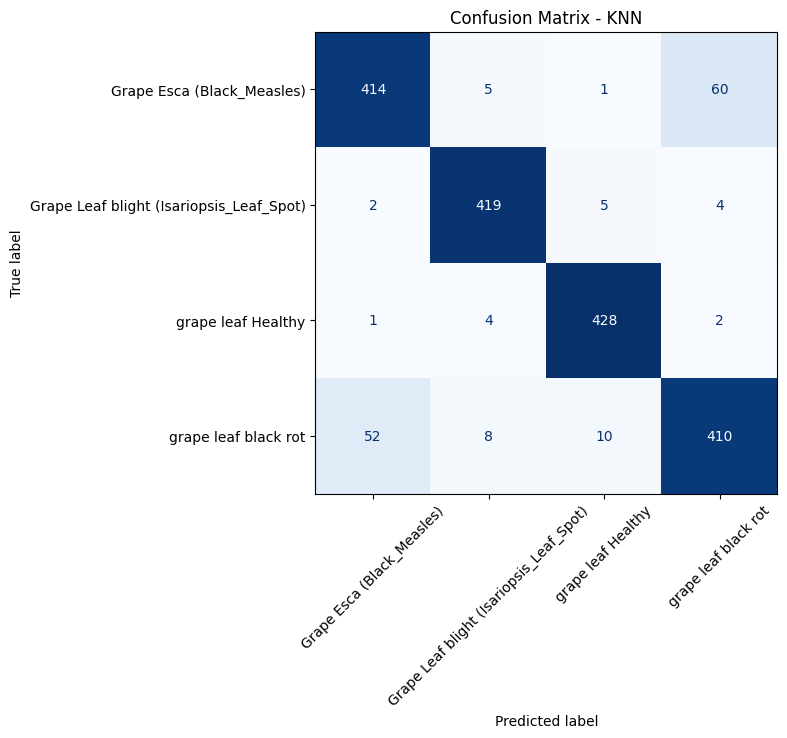

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=knn.classes_
)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - KNN")
plt.show()

In [8]:
le = LabelEncoder()

y_train_ann = le.fit_transform(train_df["label"])
y_test_ann = le.transform(valid_df["label"])

print(le.classes_)

print("Contoh y encoded:", y_train_ann[:5])

['Grape Esca (Black_Measles)' 'Grape Leaf blight (Isariopsis_Leaf_Spot)'
 'grape leaf Healthy' 'grape leaf black rot']
Contoh y encoded: [0 0 0 0 0]


In [9]:
ann = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size="auto",
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=20,
    verbose=True
)

ann.fit(X_train_scaled, y_train_ann)

Iteration 1, loss = 0.58748573
Validation score: 0.886921
Iteration 2, loss = 0.27826726
Validation score: 0.908719
Iteration 3, loss = 0.21306537
Validation score: 0.922343
Iteration 4, loss = 0.17641188
Validation score: 0.930518
Iteration 5, loss = 0.15177046
Validation score: 0.925068
Iteration 6, loss = 0.15095720
Validation score: 0.919619
Iteration 7, loss = 0.12365025
Validation score: 0.935967
Iteration 8, loss = 0.10913939
Validation score: 0.944142
Iteration 9, loss = 0.09787030
Validation score: 0.926431
Iteration 10, loss = 0.20975167
Validation score: 0.938692
Iteration 11, loss = 0.10518081
Validation score: 0.950954
Iteration 12, loss = 0.10203416
Validation score: 0.938692
Iteration 13, loss = 0.08638665
Validation score: 0.949591
Iteration 14, loss = 0.07842098
Validation score: 0.948229
Iteration 15, loss = 0.07007330
Validation score: 0.952316
Iteration 16, loss = 0.06487939
Validation score: 0.956403
Iteration 17, loss = 0.06122833
Validation score: 0.956403
Iterat

MLPClassifier(early_stopping=True, hidden_layer_sizes=(128, 64), max_iter=300,
              n_iter_no_change=20, random_state=42, verbose=True)

In [10]:
y_train_pred_ann = ann.predict(X_train_scaled)
y_test_pred_ann = ann.predict(X_test_scaled)

train_acc_ann = accuracy_score(
    y_train_ann,
    y_train_pred_ann
)

test_acc_ann = accuracy_score(
    y_test_ann,
    y_test_pred_ann
)

print("Training Accuracy:", train_acc_ann)
print("Testing Accuracy :", test_acc_ann)

print("\nClassification Report:\n")
print(classification_report(y_test_ann, y_test_pred_ann, target_names=le.classes_))

Training Accuracy: 0.9948193592365372
Testing Accuracy : 0.9605479452054795

Classification Report:

                                          precision    recall  f1-score   support

              Grape Esca (Black_Measles)       0.95      0.93      0.94       480
Grape Leaf blight (Isariopsis_Leaf_Spot)       0.99      0.99      0.99       430
                      grape leaf Healthy       0.99      0.99      0.99       435
                    grape leaf black rot       0.91      0.94      0.93       480

                                accuracy                           0.96      1825
                               macro avg       0.96      0.96      0.96      1825
                            weighted avg       0.96      0.96      0.96      1825



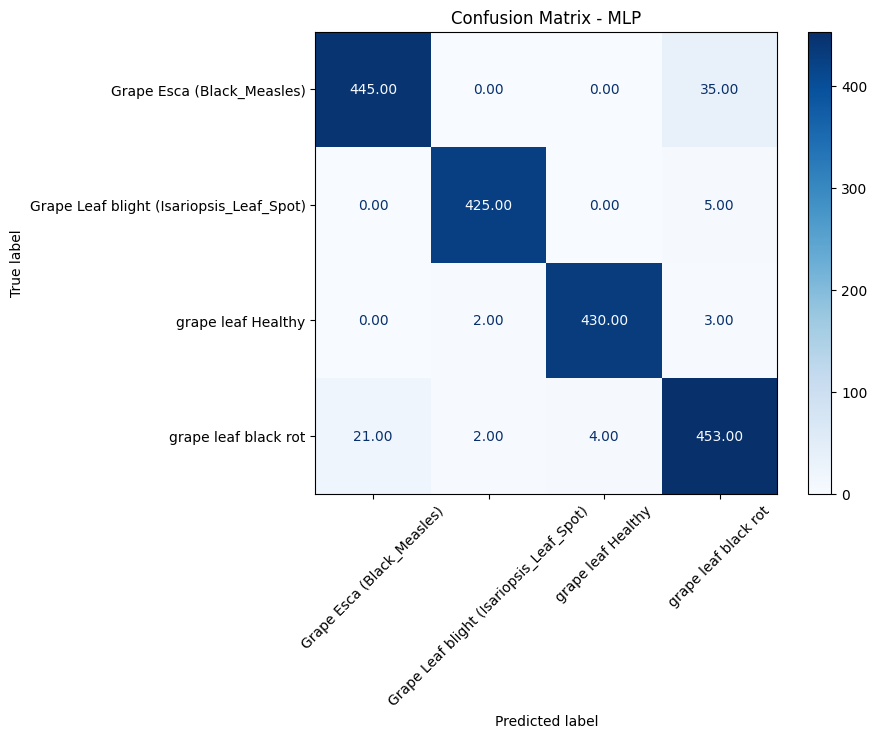

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_norm = confusion_matrix(
    y_test_ann,
    y_test_pred_ann
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(8,6))

disp.plot(
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=45,
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix - MLP")
plt.show()